# IPL Win Probability Predictor

**Goal:** given the state of a run-chase (runs needed, balls left, wickets in hand, who's
playing, where), predict the probability that the chasing team wins the match.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)


## 1. Load the data

In [2]:
ball_by_ball = pd.read_csv('ipl_ball_by_ball.csv', low_memory=False)
matches = pd.read_csv('ipl_matches.csv')

## 2. EDA and Data cleaning 

In [3]:
ball_by_ball.head()

,match_id,date,season,venue,city,innings,batting_team,bowling_team,over,ball_in_over,ball_number,batter,bowler,non_striker,batter_runs,extra_runs,total_runs,wides,noballs,byes,legbyes,penalty,is_wicket,wicket_player_out,wicket_kind,match_winner,toss_winner,toss_decision,team1,team2,is_powerplay,is_middle_overs,is_death_overs,batting_team_won
0,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,1,1,DA Warner,TS Mills,S Dhawan,0,0,0,0,0,0,0,0,0,NaN,NaN,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,Royal Challengers Bangalore,1,0,0,1
1,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,2,2,DA Warner,TS Mills,S Dhawan,0,0,0,0,0,0,0,0,0,NaN,NaN,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,Royal Challengers Bangalore,1,0,0,1
2,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,3,3,DA Warner,TS Mills,S Dhawan,4,0,4,0,0,0,0,0,0,NaN,NaN,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,Royal Challengers Bangalore,1,0,0,1
3,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,4,4,DA Warner,TS Mills,S Dhawan,0,0,0,0,0,0,0,0,0,NaN,NaN,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,Royal Challengers Bangalore,1,0,0,1
4,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,5,5,DA Warner,TS Mills,S Dhawan,0,2,2,2,0,0,0,0,0,NaN,NaN,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,Royal Challengers Bangalore,1,0,0,1


In [4]:
matches.head()

,match_id,date,city,venue,team1,team2,toss_winner,toss_decision,winner,result_type,player_of_match,season,event_name,match_type,gender,overs,balls_per_over,team1_won,toss_winner_won
0,1082591,2017-04-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"['by', 'winner']",Yuvraj Singh,2017,Indian Premier League,T20,male,20,6,1,0
1,1082592,2017-04-06,Pune,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,Rising Pune Supergiant,"['by', 'winner']",SPD Smith,2017,Indian Premier League,T20,male,20,6,1,1
2,1082593,2017-04-07,Rajkot,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,"['winner', 'by']",CA Lynn,2017,Indian Premier League,T20,male,20,6,0,1
3,1082594,2017-04-08,Indore,Holkar Cricket Stadium,Kings XI Punjab,Rising Pune Supergiant,Kings XI Punjab,field,Kings XI Punjab,"['by', 'winner']",GJ Maxwell,2017,Indian Premier League,T20,male,20,6,1,1
4,1082595,2017-04-08,Bengaluru,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,Royal Challengers Bangalore,"['winner', 'by']",KM Jadhav,2017,Indian Premier League,T20,male,20,6,1,1


In [5]:
ball_by_ball.shape

(288226, 34)

In [6]:
matches.shape

(1212, 19)

In [7]:
ball_by_ball.dtypes

match_id              int64
date                 object
season               object
venue                object
city                 object
innings               int64
batting_team         object
bowling_team         object
over                  int64
ball_in_over          int64
ball_number           int64
batter               object
bowler               object
non_striker          object
batter_runs           int64
extra_runs            int64
total_runs            int64
wides                 int64
noballs               int64
byes                  int64
legbyes               int64
penalty               int64
is_wicket             int64
wicket_player_out    object
wicket_kind          object
match_winner         object
toss_winner          object
toss_decision        object
team1                object
team2                object
is_powerplay          int64
is_middle_overs       int64
is_death_overs        int64
batting_team_won      int64
dtype: object

In [8]:
print(matches.isnull().sum()[matches.isnull().sum() > 0]) # To find missing values in matches.csv

city               51
winner             25
player_of_match     9
dtype: int64


In [9]:
print(ball_by_ball.duplicated().sum(), matches.duplicated().sum()) # To find the duplicates in both the data set 

0 0


In [10]:
print(matches['result_type'].value_counts(dropna=False)) 

result_type
['by', 'winner']              601
['winner', 'by']              564
['by', 'method', 'winner']     16
['result', 'eliminator']        9
['result']                      9
['eliminator', 'result']        7
['winner', 'by', 'method']      6
Name: count, dtype: int64


In [11]:
print(sorted(ball_by_ball['innings'].unique())) # innings values present in ball_by_ball

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [12]:
print(sorted(ball_by_ball['batting_team'].unique())) # unique batting team names

['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


A few things stand out that need to be handled :

- **Some matches have a missing `winner`** in `matches.csv` -- these are abandoned or
  washed-out games, so there's no result to learn a label from.
- **`result_type` has a `'method'` category** -- this marks matches decided under D/L
  (the rain rule). The target for the chasing team isn't simply "1st innings score + 1"
  in these matches, and our `runs_left`/`balls_left` math assumes a clean 120-ball chase,
  so keeping them would silently give the wrong target.
- **`innings` goes above 2 for some matches** -- that only happens when a match was tied
  after 20 overs and went to a Super Over. A Super Over is a completely different format
  (a one-over eliminator, not a full run-chase), so these matches would teach the model
  non-standard patterns and carry a win/loss label that doesn't reflect what actually
  happened in the normal chase. Best to remove them entirely.
- **`batting_team` mixes old and new franchise names** -- teams like Delhi Daredevils and
  Delhi Capitals are the same franchise before and after a rebrand. Left as-is, the model
  would treat them as two unrelated teams and split their history in half for no good
  reason.

In [13]:
# drop match_ids with no result, DLS involvement, or a Super Over
no_result_ids = set(matches.loc[matches['winner'].isnull(), 'match_id'])
dls_ids = set(matches.loc[matches['result_type'].str.contains('method', na=False), 'match_id'])
super_over_ids = set(ball_by_ball.loc[ball_by_ball['innings'] > 2, 'match_id'])

exclude_ids = no_result_ids | dls_ids | super_over_ids

print(f'no-result matches: {len(no_result_ids)}')
print(f'DLS-affected matches: {len(dls_ids)}')
print(f'super over matches: {len(super_over_ids)}')
print(f'total matches excluded: {len(exclude_ids)}  (out of {matches["match_id"].nunique()})')

df = ball_by_ball[~ball_by_ball['match_id'].isin(exclude_ids)].copy()

no-result matches: 25
DLS-affected matches: 22
super over matches: 16
total matches excluded: 47  (out of 1212)


In [14]:
# normalize franchise identities, then restrict to teams still active today
rename_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
}
for col in ['batting_team', 'bowling_team', 'team1', 'team2']:
    df[col] = df[col].replace(rename_map)

current_teams = [
    'Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders',
    'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals',
    'Royal Challengers Bengaluru', 'Sunrisers Hyderabad',
]

before = df['match_id'].nunique()
df = df[df['batting_team'].isin(current_teams) & df['bowling_team'].isin(current_teams)]
print(f'matches before team filter: {before}  ->  after: {df["match_id"].nunique()}')

matches before team filter: 1165  ->  after: 1056


### Why "balls left" can't just be `120 - ball_number`

Cricket only counts *legal* deliveries against the 6-balls-per-over quota. A wide or a
no-ball doesn't count -- the bowler has to bowl it again. Let's check whether this
dataset's per-ball numbering already accounts for that, or whether it naively counts
every row (legal or not).

In [15]:
sample_match = df[(df['match_id'] == df['match_id'].iloc[0]) & (df['innings'] == 1) & (df['over'] == 0)]
print(sample_match[['over', 'ball_in_over', 'ball_number', 'total_runs', 'wides', 'noballs']])
print()
rows_per_over = df.groupby(['match_id', 'innings', 'over']).size()
print('overs with MORE than 6 rows (because of a wide/no-ball):', (rows_per_over > 6).sum())

   over  ball_in_over  ball_number  total_runs  wides  noballs
0     0             1            1           0      0        0
1     0             2            2           0      0        0
2     0             3            3           4      0        0
3     0             4            4           0      0        0
4     0             5            5           2      2        0
5     0             6            6           0      0        0
6     0             7            7           1      0        0

overs with MORE than 6 rows (because of a wide/no-ball): 7815


Confirmed: this over has **7 rows**, not 6, because of one wide. `ball_number` just
counts rows in order -- it does not skip illegal deliveries. So if we used
`120 - ball_number` directly, every wide/no-ball bowled in a match would make us think
one fewer ball remains than actually does. Over a whole innings that can shift
`balls_left` by several balls, which then distorts `crr`/`rrr` too. We'll fix this
properly in the feature engineering step below by building our own legal-ball counter.

## 3. Feature engineering

For every ball of the 2nd innings, we want to know: at this exact moment, how much does
the chasing team need, how much time/wickets do they have left, and did they go on to
win? That row becomes one training example.

**Features:**
- `batting_team`, `bowling_team`, `city` -- categorical context
- `runs_left` -- target minus runs scored so far
- `balls_left` -- 120 minus *legal* balls bowled so far (see fix above)
- `wickets_left` -- 10 minus wickets fallen so far
- `target` -- runs the chasing team needs to reach (worked out below)
- `crr` -- current run rate (runs per over, at this point in the chase)
- `rrr` -- required run rate (runs per over still needed, at this point)

**Label:** `result` -- did the batting (chasing) team end up winning.

In [16]:
first_innings_runs = df[df['innings'] == 1].groupby('match_id')['total_runs'].sum()
target_by_match = (first_innings_runs + 1).to_dict()

second_innings = df[df['innings'] == 2].copy()
second_innings['target'] = second_innings['match_id'].map(target_by_match)

# make sure we process each match's deliveries in bowled order before doing cumulative sums
second_innings = second_innings.sort_values(['match_id', 'ball_number']).reset_index(drop=True)
print('2nd-innings rows to work with:', second_innings.shape[0])


2nd-innings rows to work with: 122649


In [17]:
# Filling missing city names from the venue instead of removing the matches.
venue_to_city = {
    'Dubai International Cricket Stadium': 'Dubai',
    'Sharjah Cricket Stadium': 'Sharjah',
}
missing_before = second_innings['city'].isnull().sum()
second_innings['city'] = second_innings['city'].fillna(second_innings['venue'].map(venue_to_city))
print(f'rows with missing city: {missing_before} -> {second_innings["city"].isnull().sum()}')


rows with missing city: 5641 -> 0


In [19]:
# --- current_score & runs_left ---
second_innings['current_score'] = second_innings.groupby('match_id')['total_runs'].cumsum()
second_innings['runs_left'] = second_innings['target'] - second_innings['current_score']

# a delivery only counts against the 120-ball quota if it's neither a wide nor a no-ball
second_innings['is_legal_ball'] = ((second_innings['wides'] == 0) & (second_innings['noballs'] == 0)).astype(int)
second_innings['legal_balls_bowled'] = second_innings.groupby('match_id')['is_legal_ball'].cumsum()
second_innings['balls_left'] = 120 - second_innings['legal_balls_bowled']

# --- wickets_left ---
second_innings['wickets_lost'] = second_innings.groupby('match_id')['is_wicket'].cumsum()
second_innings['wickets_left'] = 10 - second_innings['wickets_lost']

# --- run rates ---
second_innings['crr'] = (second_innings['current_score'] * 6) / second_innings['legal_balls_bowled']
second_innings['rrr'] = np.where(
    second_innings['balls_left'] > 0,
    (second_innings['runs_left'] * 6) / second_innings['balls_left'],
    np.nan,
)

# Using the existing 'batting_team_won' column as the target label.
second_innings['result'] = second_innings['batting_team_won']

second_innings[['over', 'ball_in_over', 'current_score', 'runs_left', 'balls_left',
                'wickets_left', 'crr', 'rrr', 'result']].tail()


,over,ball_in_over,current_score,runs_left,balls_left,wickets_left,crr,rrr,result
122644,18,4,216,10,8,7,11.571429,7.500000,1
122645,18,5,217,9,7,7,11.522124,7.714286,1
122646,18,6,221,5,6,7,11.631579,5.000000,1
122647,19,1,225,1,5,7,11.739130,1.200000,1
122648,19,2,226,0,5,7,11.791304,0.000000,1


### Handling Edge Cases

Before training the model, we handle a few edge cases:

- **Negative `runs_left`:** This happens when the winning shot scores more runs than required (e.g., needing 2 runs but hitting a six). These rows are valid, so we keep them.
- **Infinite `crr`:** This occurs when the first ball is a wide, causing division by zero while calculating the current run rate. Since there are only a few such cases, we remove them.
- **`balls_left == 0`:** We remove the last ball of each innings because the required run rate is no longer meaningful once the innings has ended.

In [ ]:
final_df = second_innings[[
    'batting_team', 'bowling_team', 'city',
    'runs_left', 'balls_left', 'wickets_left', 'target', 'crr', 'rrr', 'result',
]].copy()

rows_before = final_df.shape[0]
final_df = final_df[final_df['balls_left'] > 0]
final_df = final_df.replace([np.inf, -np.inf], np.nan).dropna()
print(f'Rows before cleaning: {rows_before}  ->  after: {final_df.shape[0]}')
print()
print("Class balance:")
print(final_df['result'].value_counts(normalize=True).rename('share'))
print()
final_df.describe()

Rows before cleaning: 122649  ->  after: 122183

Class balance:
result
1    0.518738
0    0.481262
Name: share, dtype: float64



,runs_left,balls_left,wickets_left,target,crr,rrr,result
count,122183.000000,122183.000000,122183.000000,122183.000000,122183.000000,122183.000000,122183.000000
mean,96.265119,62.978393,7.503343,172.553874,7.843435,10.971465,0.518738
std,51.891917,33.219170,2.161333,32.311799,2.530150,13.424265,0.499651
min,-5.000000,1.000000,0.000000,68.000000,0.000000,-30.000000,0.000000
25%,55.000000,35.000000,6.000000,152.000000,6.518519,7.378378,0.000000
50%,95.000000,64.000000,8.000000,172.000000,7.800000,9.171429,1.000000
75%,135.000000,92.000000,9.000000,193.000000,9.135749,11.425809,1.000000
max,287.000000,119.000000,10.000000,288.000000,60.000000,714.000000,1.000000


## 4. Train/Test Split

Each row represents a ball and not an entire match, using a random row-wise split can place balls from the same match in both the training and testing sets. This gives the model information about matches it should not have seen.

To avoid this, we split the data **match-wise**, ensuring that all balls from a match belong entirely to either the training set or the testing set.

Both methods are compared below :

In [ ]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

feature_cols = ['batting_team', 'bowling_team', 'city', 'runs_left', 'balls_left',
                'wickets_left', 'target', 'crr', 'rrr']

# Keep match_id for grouped split.
X = second_innings.loc[final_df.index, feature_cols + ['match_id']]
y = final_df['result']

# One-hot encode categorical columns
preprocessor = ColumnTransformer([
    ('one_hot', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'),
     ['batting_team', 'bowling_team', 'city']),
], remainder='passthrough')

def make_pipeline(model):
    return Pipeline([('prep', preprocessor), ('model', model)])

def evaluate(name, pipe, X_train, X_test, y_train, y_test):
    pipe.fit(X_train[feature_cols], y_train)
    preds = pipe.predict(X_test[feature_cols])
    probs = pipe.predict_proba(X_test[feature_cols])[:, 1]
    print(f'{name:32s} accuracy={accuracy_score(y_test, preds):.4f}   '
          f'log-loss={log_loss(y_test, probs):.4f}   brier={brier_score_loss(y_test, probs):.4f}')


In [ ]:
print('=== row level split: individual balls shuffled at random ===')
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=1)
evaluate('Logistic Regression', make_pipeline(LogisticRegression(solver='liblinear')), Xtr, Xte, ytr, yte)
evaluate('Random Forest', make_pipeline(RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)), Xtr, Xte, ytr, yte)


=== naive split: individual balls shuffled at random ===
Logistic Regression              accuracy=0.7979   log-loss=0.4138   brier=0.1351
Random Forest                    accuracy=0.9978   log-loss=0.0416   brier=0.0056


In [ ]:
print('=== match level split: every match goes entirely to train OR entirely to test ===')
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=1)
train_idx, test_idx = next(splitter.split(X, y, groups=X['match_id']))
Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
ytr, yte = y.iloc[train_idx], y.iloc[test_idx]
print(f'train matches: {Xtr["match_id"].nunique()}   test matches: {Xte["match_id"].nunique()}')
print()
evaluate('Logistic Regression', make_pipeline(LogisticRegression(solver='liblinear')), Xtr, Xte, ytr, yte)
evaluate('Random Forest', make_pipeline(RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)), Xtr, Xte, ytr, yte)
evaluate('Random Forest (max_depth=12)', make_pipeline(RandomForestClassifier(n_estimators=300, max_depth=12, random_state=1, n_jobs=-1)), Xtr, Xte, ytr, yte)


=== proper split: every match goes entirely to train OR entirely to test ===
train matches: 844   test matches: 212

Logistic Regression              accuracy=0.7641   log-loss=0.4758   brier=0.1561
Random Forest                    accuracy=0.7430   log-loss=0.5047   brier=0.1684
Random Forest (max_depth=12)     accuracy=0.7592   log-loss=0.4751   brier=0.1563


**Results:** With a random row-wise split, Random Forest achieved very high accuracy because balls from the same match appeared in both the training and testing sets. After switching to a match-wise split, its performance dropped to a more realistic level and was similar to (or slightly lower than) Logistic Regression.

**Final Model:** Since Logistic Regression performed as well as Random Forest on the match-wise split, while being simpler, faster, and providing better probability estimates, it was chosen as the final model.

## 5. Calibration Curve

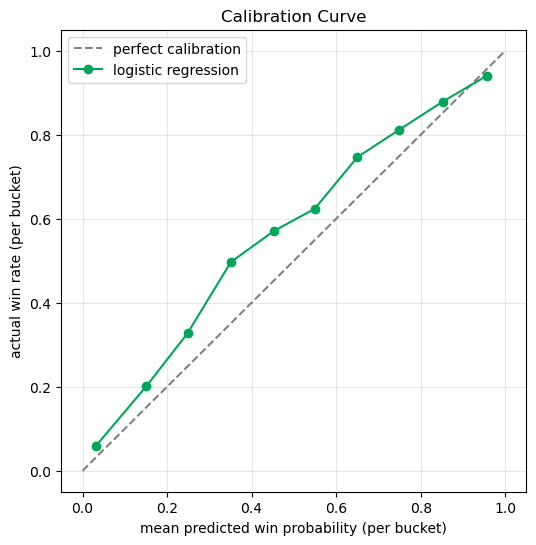

In [23]:
from sklearn.calibration import calibration_curve

final_pipe = make_pipeline(LogisticRegression(solver='liblinear'))
final_pipe.fit(Xtr[feature_cols], ytr)
test_probs = final_pipe.predict_proba(Xte[feature_cols])[:, 1]

actual_rate, predicted_rate = calibration_curve(yte, test_probs, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='perfect calibration')
plt.plot(predicted_rate, actual_rate, marker='o', color='#00a65a', label='logistic regression')
plt.xlabel('mean predicted win probability (per bucket)')
plt.ylabel('actual win rate (per bucket)')
plt.title('Calibration Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


The curve is close to the diagonal, so the model gives reliable win probabilities.

## 6. Model Prediction on a Match

In [24]:
def match_progression(match_id, source_df, pipe):
    """Return the win probability after each over for a given match.
    """
    match_rows = source_df[source_df['match_id'] == match_id]
    end_of_over = match_rows.groupby('over').tail(1)  # state at the last ball of each over
    probs = pipe.predict_proba(end_of_over[feature_cols])[:, 1]

    progression = pd.DataFrame({
        'over': end_of_over['over'].values + 1,
        'runs_left': end_of_over['runs_left'].values,
        'wickets_left': end_of_over['wickets_left'].values,
        'win_probability_%': np.round(probs * 100, 1),
    })
    context = {
        'batting_team': end_of_over['batting_team'].iloc[0],
        'bowling_team': end_of_over['bowling_team'].iloc[0],
        'target': int(end_of_over['target'].iloc[0]),
    }
    return progression, context

# Selecting a match from the test set.
sample_match_id = Xte['match_id'].iloc[0]
progression, context = match_progression(sample_match_id, second_innings, final_pipe)
print(f"{context['batting_team']} chasing {context['target']} against {context['bowling_team']}")
progression


Delhi Capitals chasing 130 against Rajasthan Royals


,over,runs_left,wickets_left,win_probability_%
0,1,122,10,78.6
1,2,109,9,79.2
2,3,104,9,79.4
3,4,94,9,84.1
4,5,82,9,89.1
5,6,75,9,90.6
6,7,71,9,90.6
7,8,59,9,94.0
8,9,52,9,95.0
9,10,44,9,96.2


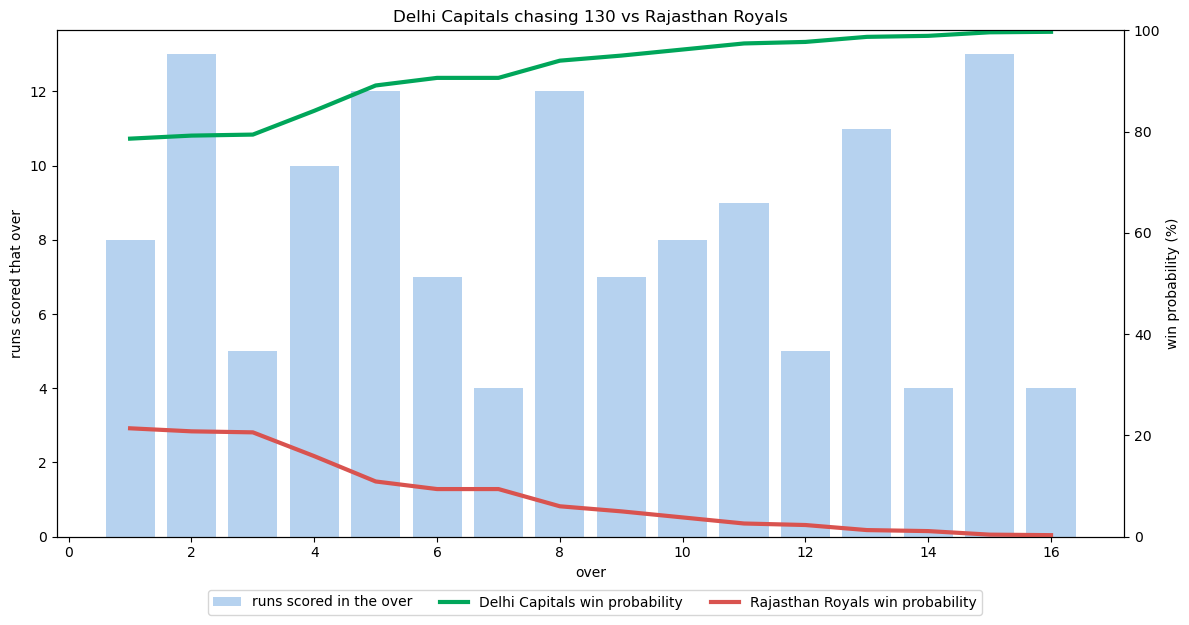

In [25]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Calculate runs scored in each over.
prev_runs_left = progression['runs_left'].shift(1)
prev_runs_left.iloc[0] = context['target']
runs_scored_per_over = prev_runs_left - progression['runs_left']

ax1.bar(progression['over'], runs_scored_per_over,
        color='#4a90d9', alpha=0.4, label='runs scored in the over')
ax1.set_xlabel('over')
ax1.set_ylabel('runs scored that over')

ax2 = ax1.twinx()
ax2.plot(progression['over'], progression['win_probability_%'], color='#00a65a', linewidth=3,
         label=f"{context['batting_team']} win probability")
ax2.plot(progression['over'], 100 - progression['win_probability_%'], color='#d9534f', linewidth=3,
         label=f"{context['bowling_team']} win probability")
ax2.set_ylabel('win probability (%)')
ax2.set_ylim(0, 100)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3)
plt.title(f"{context['batting_team']} chasing {context['target']} vs {context['bowling_team']}")
plt.tight_layout()
plt.show()


The predicted win probability changes with the progress of the match, showing that the model reacts to the changing match situation.

## 7. Trained the Final Model and Saving It

In [26]:
import pickle

production_pipe = make_pipeline(LogisticRegression(solver='liblinear'))
production_pipe.fit(X[feature_cols], y)

with open('ipl_win_predictor_pipeline.pkl', 'wb') as f:
    pickle.dump(production_pipe, f)

print(f"Model trained on {X.shape[0]} deliveries from {X['match_id'].nunique()} matches.")

Model trained on 122183 deliveries from 1056 matches.
